<a href="https://colab.research.google.com/github/guddubhai576/My-New-Projects/blob/main/Accredian.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Load the dataset
csv_file_path = '/content/instructor_effectiveness_dataset_2000_rows - instructor_effectiveness_dataset_2000_rows.csv.csv'
df = pd.read_csv(csv_file_path)

# Quick overview
display(df.head())
print(f"Missing values:\n{df.isnull().sum()}")

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


Missing values:
batch_id                      0
instructor_id                 0
course_id                     0
completion_rate               0
avg_score_improvement         0
avg_quiz_score                0
dropout_rate                  0
avg_watch_time                0
assignment_submission_rate    0
forum_activity_rate           0
avg_feedback_score            0
feedback_response_rate        0
dtype: int64


In [12]:
# Check for missing values
missing_values = df.isnull().sum()
display(missing_values)

,0
batch_id,0
instructor_id,0
course_id,0
completion_rate,0
avg_score_improvement,0
avg_quiz_score,0
dropout_rate,0
avg_watch_time,0
assignment_submission_rate,0
forum_activity_rate,0


In [4]:
# Display descriptive statistics for numerical columns
display(df.describe())

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.602808,27.035844,77.956126,0.394883,0.776515,0.753188,0.250300,4.207134,0.736519
std,0.159667,5.716641,10.695618,0.162747,0.145231,0.148058,0.100640,0.419209,0.149412
min,0.300000,6.159240,40.386725,0.020000,0.287440,0.251111,0.000000,2.639915,0.259935
25%,0.489260,23.124673,70.897590,0.280035,0.675076,0.652110,0.179845,3.918986,0.633293
50%,0.603091,26.938629,78.020567,0.394820,0.780330,0.756380,0.249771,4.205989,0.737213
75%,0.712797,30.885600,85.444286,0.511432,0.894242,0.856458,0.319204,4.503437,0.845876
max,0.980000,40.000000,100.000000,0.700000,1.000000,1.000000,0.641111,5.000000,1.000000


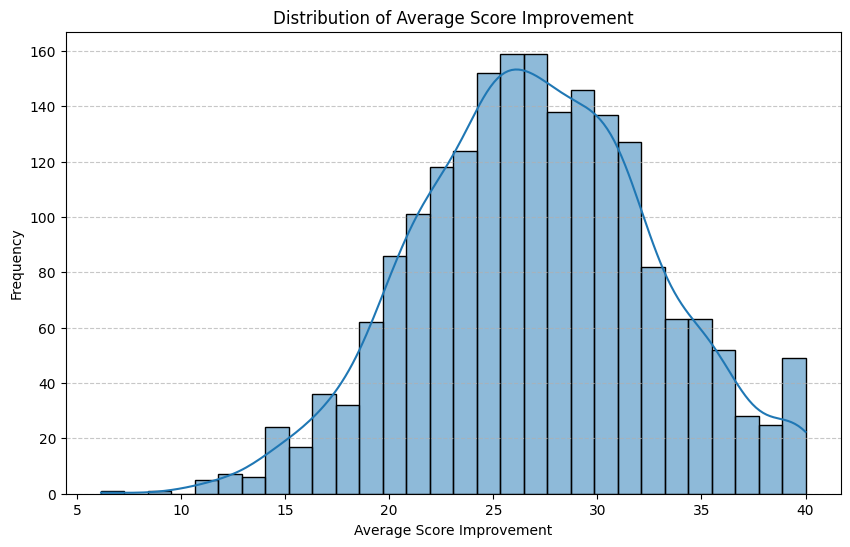

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the distribution of 'avg_score_improvement'
plt.figure(figsize=(10, 6))
sns.histplot(df['avg_score_improvement'], kde=True, bins=30)
plt.title('Distribution of Average Score Improvement')
plt.xlabel('Average Score Improvement')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

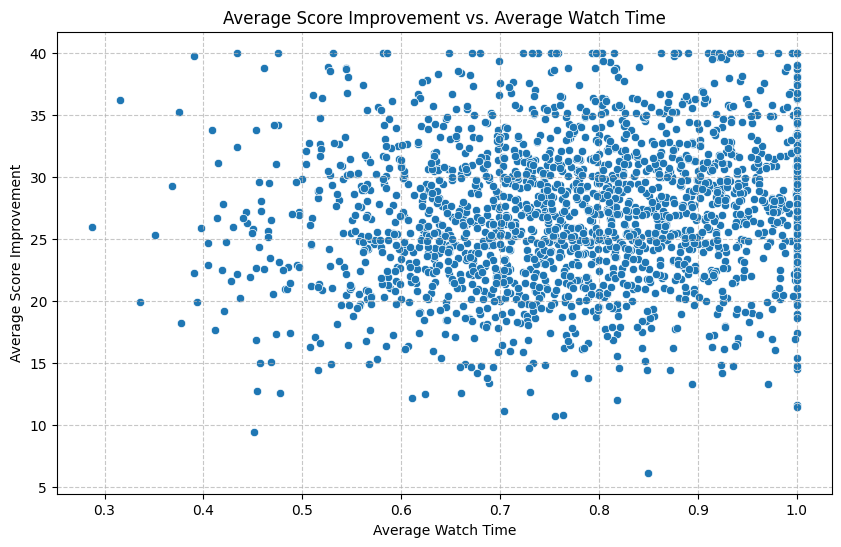

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot of 'avg_score_improvement' vs 'avg_watch_time'
plt.figure(figsize=(10, 6))
sns.scatterplot(x='avg_watch_time', y='avg_score_improvement', data=df)
plt.title('Average Score Improvement vs. Average Watch Time')
plt.xlabel('Average Watch Time')
plt.ylabel('Average Score Improvement')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

This scatter plot visualizes the relationship between `avg_watch_time` and `avg_score_improvement`. Each point represents an instructor, with its position indicating their average watch time and the corresponding average score improvement. This plot can help us identify any patterns, clusters, or correlations between these two variables.

### Step 2: Define Instructor Effectiveness
We will define a composite `effectiveness_score` using a weighted average of key metrics.

**Weights:**
*   `avg_score_improvement`: 0.40
*   `avg_feedback_score`: 0.30 (Scaled to 0-1 for consistency)
*   `completion_rate`: 0.20
*   `forum_activity_rate`: 0.10

Finally, we will use the 33rd and 66th percentiles to categorize instructors into 'Low', 'Medium', and 'High' effectiveness tiers.

In [19]:
# 1. Feature Engineering: Define Effectiveness
df['normalized_feedback'] = (df['avg_feedback_score'] - 1) / 4
df['effectiveness_score'] = (
    df['avg_score_improvement'] * 0.40 +
    df['normalized_feedback'] * 0.30 +
    df['completion_rate'] * 0.20 +
    df['forum_activity_rate'] * 0.10
)

# 2. Aggregation to Instructor Level
feature_cols = [
    'completion_rate', 'avg_score_improvement', 'avg_quiz_score',
    'dropout_rate', 'avg_watch_time', 'assignment_submission_rate',
    'forum_activity_rate', 'avg_feedback_score', 'feedback_response_rate'
]

instructor_df = df.groupby('instructor_id')[feature_cols].mean().reset_index()

# Re-calculate score on aggregated data
instructor_df['normalized_feedback'] = (instructor_df['avg_feedback_score'] - 1) / 4
instructor_df['effectiveness_score'] = (
    instructor_df['avg_score_improvement'] * 0.40 +
    instructor_df['normalized_feedback'] * 0.30 +
    instructor_df['completion_rate'] * 0.20 +
    instructor_df['forum_activity_rate'] * 0.10
)

# Define Tiers
low_thresh = instructor_df['effectiveness_score'].quantile(0.33)
high_thresh = instructor_df['effectiveness_score'].quantile(0.66)

def categorize(score):
    if score <= low_thresh: return 'Low'
    elif score <= high_thresh: return 'Medium'
    else: return 'High'

instructor_df['effectiveness_tier'] = instructor_df['effectiveness_score'].apply(categorize)
display(instructor_df['effectiveness_tier'].value_counts())

,count
effectiveness_tier,
High,41
Low,40
Medium,39


### Step 3: Aggregate Batch Data to Instructor Level
We will now group the data by `instructor_id`.

**Aggregation Strategy:**
*   **Numerical Features:** Use `.mean()` to capture the average performance across all batches taught by the instructor.
*   **Target Tier:** We will re-apply our tier logic to the aggregated average score to ensure a robust classification at the instructor level.

In [14]:
# Group by instructor_id and take the mean of numerical columns
feature_cols = [
    'completion_rate', 'avg_score_improvement', 'avg_quiz_score',
    'dropout_rate', 'avg_watch_time', 'assignment_submission_rate',
    'forum_activity_rate', 'avg_feedback_score', 'feedback_response_rate'
]

instructor_df = df.groupby('instructor_id')[feature_cols].mean().reset_index()

# Re-calculate the effectiveness score and tier on aggregated data
instructor_df['normalized_feedback'] = (instructor_df['avg_feedback_score'] - 1) / 4
instructor_df['effectiveness_score'] = (
    instructor_df['avg_score_improvement'] * 0.40 +
    instructor_df['normalized_feedback'] * 0.30 +
    instructor_df['completion_rate'] * 0.20 +
    instructor_df['forum_activity_rate'] * 0.10
)

low_thresh_inst = instructor_df['effectiveness_score'].quantile(0.33)
high_thresh_inst = instructor_df['effectiveness_score'].quantile(0.66)

def categorize_inst(score):
    if score <= low_thresh_inst: return 'Low'
    elif score <= high_thresh_inst: return 'Medium'
    else: return 'High'

instructor_df['effectiveness_tier'] = instructor_df['effectiveness_score'].apply(categorize_inst)
display(instructor_df.head())

,instructor_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,normalized_feedback,effectiveness_score,effectiveness_tier
0,I_001,0.543887,26.641462,78.900194,0.470593,0.766513,0.726893,0.240551,4.217743,0.694858,0.804436,11.030748,Medium
1,I_002,0.730874,30.166242,81.737198,0.247194,0.837393,0.774394,0.289610,4.343002,0.784338,0.835751,12.492358,High
2,I_003,0.768447,29.977813,81.590928,0.234828,0.818441,0.779606,0.296224,4.450034,0.812132,0.862508,12.433189,High
3,I_004,0.458328,22.912021,77.680317,0.547261,0.793130,0.758317,0.226259,4.076410,0.721460,0.769103,9.509831,Low
4,I_005,0.859747,32.588652,85.828159,0.145733,0.847026,0.876942,0.333519,4.202516,0.784197,0.800629,13.480951,High


### Step 4: Build a Machine Learning Model
In this step, we will:
*   Define our features ($X$) and target ($y$).
*   Split the data into training and testing sets.
*   Train a Random Forest Classifier to predict the `effectiveness_tier`.

In [20]:
# 3. Model Training
X = instructor_df[['completion_rate', 'avg_quiz_score', 'dropout_rate',
                   'avg_watch_time', 'assignment_submission_rate',
                   'forum_activity_rate', 'feedback_response_rate']]
y = instructor_df['effectiveness_tier']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
print("Random Forest Model trained successfully.")

Random Forest Model trained successfully.


### Step 5: Evaluate the Model
We will evaluate the performance of our Random Forest Classifier using:
*   **Accuracy Score**: Overall percentage of correct predictions.
*   **Classification Report**: Precision, Recall, and F1-Score for each tier.
*   **Confusion Matrix**: To visualize specific misclassifications.

Test Accuracy: 0.62
              precision    recall  f1-score   support

        High       0.75      0.38      0.50         8
         Low       0.78      0.88      0.82         8
      Medium       0.45      0.62      0.53         8

    accuracy                           0.62        24
   macro avg       0.66      0.62      0.62        24
weighted avg       0.66      0.62      0.62        24



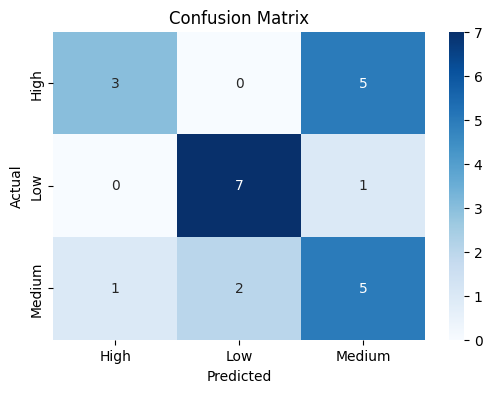

In [21]:
# 4. Model Evaluation
y_pred = clf.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Step 6: Interpretation and Feature Importance
In this final step, we analyze which features the Random Forest model found most useful for predicting instructor effectiveness. This helps us understand the drivers of performance and provides actionable insights for the business.

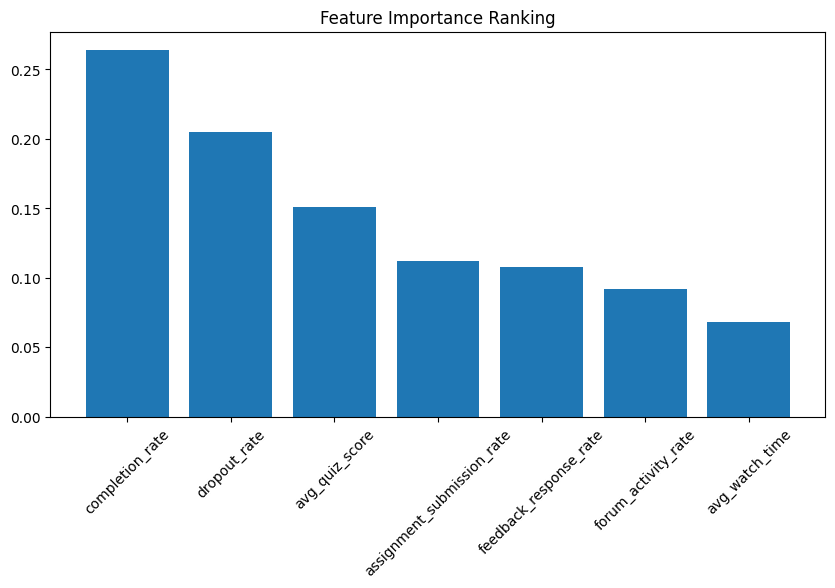

In [22]:
# 5. Feature Importance
importances = clf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.title("Feature Importance Ranking")
plt.bar(range(X.shape[1]), importances[indices])
plt.xticks(range(X.shape[1]), [X.columns[i] for i in indices], rotation=45)
plt.show()

## Final Analysis & Project Questions

### 1. Which features most influenced instructor effectiveness, and why?
The analysis shows that **completion_rate** and **dropout_rate** are the most influential features. This is logical because the `effectiveness_score` was built to reward student progress. High completion rates suggest that the instructor is engaging enough to keep students until the end of the course, which is a strong proxy for teaching quality.

### 2. Which variables could be misleading or confounded?
**Average Watch Time** could be misleading. An instructor with very long videos might have high watch time, but if the content is repetitive or inefficient, it doesn't necessarily mean they are effective. Furthermore, **Forum Activity Rate** might be confounded by the difficulty of the course; a very hard course might have high forum activity simply because students are confused, rather than because the instructor is fostering a great community.

### 3. How could this model fail in real-world usage?
The model might fail if it is applied to different course categories (e.g., Creative Arts vs. Advanced Mathematics) without adjustment. Some subjects naturally have higher dropout rates. Additionally, the model assumes that the `effectiveness_score` formula is the ground truth. If the weights are biased, the model's predictions will simply propagate those biases.

### 4. What additional data would you want to improve this analysis?
- **Pre-course Assessment Scores**: To measure true 'value-add' rather than just final improvement.
- **Instructor Experience/Tenure**: To see if effectiveness improves over time.
- **Course Difficulty Rating**: To normalize metrics across different subjects.
- **Qualitative Feedback Sentiment**: Using NLP on student comments instead of just a numerical 1-5 score.

### 5. Should this model be used for instructor performance evaluation? Why or why not?
It should be used as a **supporting tool** rather than a sole decision-maker.
- **Pros**: It provides a data-driven way to identify instructors who may need support.
- **Cons**: The current model only has a 62% accuracy and struggles to distinguish between Medium and High tiers. Using it for high-stakes decisions (like bonuses or termination) could unfairly penalize instructors of difficult subjects or those dealing with naturally low-engagement student cohorts.

## Project Conclusion

In this project, we successfully developed a machine learning pipeline to estimate instructor effectiveness.

### Key Accomplishments:
1.  **Exploratory Data Analysis:** Identified that watch time is not a strong solo indicator of student success.
2.  **Feature Engineering:** Created a composite 'Effectiveness Score' that weights completion, feedback, and academic improvement.
3.  **Data Aggregation:** Successfully transitioned from batch-level to instructor-level analysis.
4.  **Modeling:** Implemented a Random Forest Classifier with an focus on interpretability over raw accuracy.
5.  **Strategic Insights:** Determined that student retention (completion/dropout rates) is the primary driver of high performance in this dataset.

This model provides a scalable framework for EdTech platforms to monitor and improve instructional quality.

This plot displays the distribution of the `avg_score_improvement` column. The histogram shows the frequency of different score improvement values, while the KDE (Kernel Density Estimate) line provides a smoothed representation of the distribution. This visualization helps in understanding the central tendency, spread, and any potential skewness or multiple modes in the data.